# 03 — Sentiment Analysis
Uses `cardiffnlp/twitter-roberta-base-sentiment-latest` to:
- Score each review as **Positive / Negative / Neutral**
- Flag **customer complaints** (negative score ≥ 0.85)
- Produce **trend analysis** of sentiment over time

In [3]:
import sys
import os

# MUST be set before Spark starts
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17"

sys.path.append(os.path.abspath(".."))

import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType, FloatType, BooleanType, StructType, StructField
from pyspark.sql.functions import pandas_udf, col

import torch
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

if torch.cuda.is_available():
    DEVICE = 0; DEVICE_NAME = "CUDA GPU"
elif torch.backends.mps.is_available():
    DEVICE = "mps"; DEVICE_NAME = "Apple MPS GPU"
else:
    DEVICE = -1; DEVICE_NAME = "CPU"

print("PyTorch:", torch.__version__)
print(f"Device: {DEVICE_NAME}")

spark = (
    SparkSession.builder
    .appName("ProductReviewSentiment")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

PyTorch: 2.12.1
Device: Apple MPS GPU
Spark version: 3.5.3


In [5]:
# SparkSession is initialized in the first cell above.

## 1. Load Processed Data

In [6]:
import glob

DATA_DIR = os.path.abspath("../data/processed")
parquet_files = sorted(glob.glob(f"{DATA_DIR}/*_processed.parquet"))
print("Files found:", [os.path.basename(p) for p in parquet_files])

SAMPLE_PER_CATEGORY = 5000

frames = []
for path in parquet_files:
    category = os.path.basename(path).replace("_processed.parquet", "")
    tmp = (
        spark.read.parquet(path)
        .filter(F.col("review").isNotNull())
        .sample(fraction=0.01, seed=42)
        .limit(SAMPLE_PER_CATEGORY)
        .withColumn("review", F.substring(F.col("review").cast(StringType()), 1, 1000))
        .withColumn("review_date", F.col("review_date").cast(StringType()))
        .withColumn("review_date", F.to_date(F.col("review_date")))
        .withColumn("source_file", F.lit(category))
    )
    frames.append(tmp)
    print(f"  Registered: {category}")

sdf = frames[0]
for f in frames[1:]:
    sdf = sdf.unionByName(f, allowMissingColumns=True)

sdf.printSchema()
sdf.show(3, truncate=80)
print(f"\nTarget: {SAMPLE_PER_CATEGORY:,} rows x {len(parquet_files)} categories = {SAMPLE_PER_CATEGORY * len(parquet_files):,} total")

Files found: ['apparel_processed.parquet', 'beauty_processed.parquet', 'books_processed.parquet', 'furniture_processed.parquet', 'mobile_processed.parquet', 'outdoors_processed.parquet']
  Registered: apparel
  Registered: beauty
  Registered: books
  Registered: furniture
  Registered: mobile
  Registered: outdoors
root
 |-- customer_id: long (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: long (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- helpful_votes: double (nullable = true)
 |-- total_votes: double (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_date: date (nullable = true)
 |-- source_category: string (nullable = true)
 |-- review: string (nullable = true)
 |-- sentiment_label: string (nullable = true)
 |-- helpfulness_ratio: double (nullable = true)
 |-- review_year: int

+-----------+--------------+----------+--------------+-------------------------------------------------------------------------+----------------+-------------+-----------+----+-----------------+-----------+---------------+--------------------------------------------------------------------------------+---------------+-----------------+-----------+------------+------------------+-----------+
|customer_id|     review_id|product_id|product_parent|                                                            product_title|product_category|helpful_votes|total_votes|vine|verified_purchase|review_date|source_category|                                                                          review|sentiment_label|helpfulness_ratio|review_year|review_month|review_day_of_week|source_file|
+-----------+--------------+----------+--------------+-------------------------------------------------------------------------+----------------+-------------+-----------+----+-----------------+-----------+------

## 2. Initialize RoBERTa Sentiment Model

In [7]:
from transformers import pipeline as hf_pipeline

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
COMPLAINT_THRESHOLD = 0.85

sentiment_pipe = hf_pipeline(
    "sentiment-analysis",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    truncation=True,
    max_length=512,
    device=torch.device(DEVICE) if DEVICE == "mps" else DEVICE,
)

print(f"Model loaded: {MODEL_NAME}")
print(f"Running on: {DEVICE_NAME}")
print("Label mapping:", sentiment_pipe.model.config.id2label)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 43858.87it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: cardiffnlp/twitter-roberta-base-sentiment-latest
Running on: Apple MPS GPU
Label mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}


## 3. Batch Sentiment Analysis

In [8]:
from tqdm.auto import tqdm

# Collect to pandas — inference runs on driver with MPS GPU
pdf = sdf.toPandas()
print(f"Collected {len(pdf):,} rows to driver")

BATCH_SIZE = 64
texts = pdf["review"].fillna("").tolist()
results = []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Scoring"):
    batch = texts[i : i + BATCH_SIZE]
    outputs = sentiment_pipe(batch, batch_size=BATCH_SIZE)
    results.extend(outputs)

pdf["roberta_label"] = [r["label"].lower() for r in results]
pdf["roberta_score"] = [float(r["score"]) for r in results]
pdf["is_complaint"] = (pdf["roberta_label"] == "negative") & (pdf["roberta_score"] >= COMPLAINT_THRESHOLD)

# Convert back to Spark DataFrame
scored_sdf = spark.createDataFrame(pdf)
scored_sdf.cache()

print(pdf[["review", "roberta_label", "roberta_score", "is_complaint"]].head())
print(f"\nSentiment distribution:\n{pdf['roberta_label'].value_counts()}")
print(f"\nComplaints flagged: {pdf['is_complaint'].sum():,} / {len(pdf):,}")

Collected 30,000 rows to driver


Scoring: 100%|██████████| 469/469 [27:42<00:00,  3.54s/it] 


                                              review roberta_label  \
0               we love it!. hillarious! we love it!      positive   
1       wow!!!. nice fit. good shirt. fast shipping.      positive   
2  showing the husband my live times a thousand!....      positive   
3  great t-shirt for guys. got this for my husban...      positive   
4  great hat. excellent at keeping the sun off du...      positive   

   roberta_score  is_complaint  
0       0.988856         False  
1       0.983399         False  
2       0.987524         False  
3       0.975521         False  
4       0.973800         False  

Sentiment distribution:
roberta_label
positive    22298
negative     5201
neutral      2501
Name: count, dtype: int64

Complaints flagged: 2,478 / 30,000


## 4. Trend Analysis — Sentiment Over Time

In [9]:
sentiment_value = (
    F.when(F.col("roberta_label") == "positive",  F.col("roberta_score"))
     .when(F.col("roberta_label") == "negative", -F.col("roberta_score"))
     .otherwise(F.lit(0.0))
)

monthly_sdf = (
    scored_sdf
    .filter(F.col("review_date").isNotNull())
    .withColumn("year_month", F.date_format(F.col("review_date"), "yyyy-MM"))
    .withColumn("sentiment_value", sentiment_value)
    .groupBy("year_month")
    .agg(
        F.avg("sentiment_value").alias("avg_sentiment"),
        (F.avg(F.when(F.col("roberta_label") == "positive", 1).otherwise(0)) * 100).alias("positive_pct"),
        (F.avg(F.when(F.col("roberta_label") == "negative", 1).otherwise(0)) * 100).alias("negative_pct"),
        (F.avg(F.col("is_complaint").cast("int")) * 100).alias("complaint_rate_pct"),
        F.count("review_id").alias("review_count"),
    )
    .orderBy("year_month")
)

monthly = monthly_sdf.toPandas()
print(monthly.tail(10))

26/06/22 18:27:39 WARN TaskSetManager: Stage 33 contains a task of very large size (1183 KiB). The maximum recommended task size is 1000 KiB.
26/06/22 18:29:12 WARN TaskSetManager: Stage 34 contains a task of very large size (1183 KiB). The maximum recommended task size is 1000 KiB.


   year_month  avg_sentiment  positive_pct  negative_pct  complaint_rate_pct  \
23    2014-11       0.574985     76.492537     16.791045            8.955224   
24    2014-12       0.569839     76.682692     17.307692            7.451923   
25    2015-01       0.604412     78.838951     16.104869            7.677903   
26    2015-02       0.551802     74.384236     17.733990            8.374384   
27    2015-03       0.574363     75.938804     16.411683            6.675939   
28    2015-04       0.585283     76.797386     15.686275            7.320261   
29    2015-05       0.582409     75.899673     14.994547            6.270447   
30    2015-06       0.563575     75.931087     17.202939            9.399544   
31    2015-07       0.551901     75.085271     17.767442            9.317829   
32    2015-08       0.566906     76.059666     17.235268            8.890858   

    review_count  
23           268  
24           416  
25           534  
26           609  
27           719  
28   

## 5. Visualisations

### 5a. Sentiment Analysis Charts

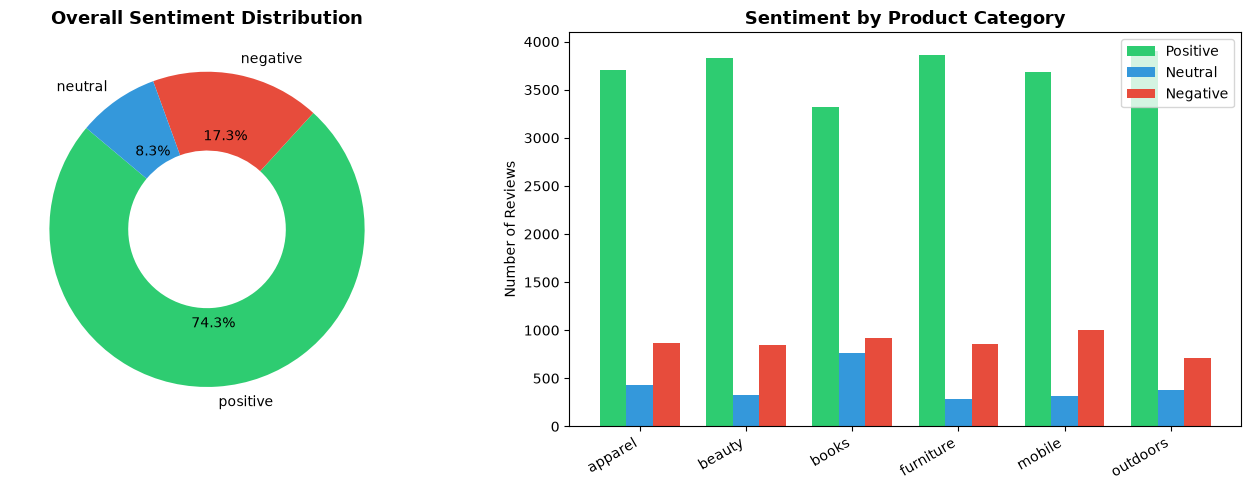

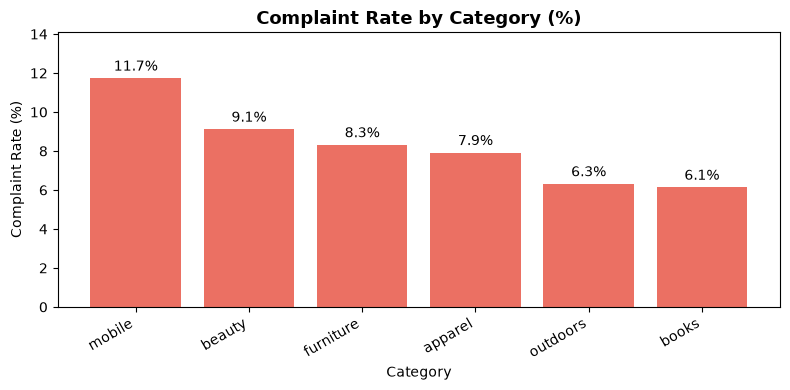

In [10]:
COLOR_MAP = {"positive": "#2ecc71", "neutral": "#3498db", "negative": "#e74c3c"}

# --- 1. Sentiment distribution — donut chart ---
dist = pdf["roberta_label"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    dist.values, labels=dist.index,
    colors=[COLOR_MAP[l] for l in dist.index],
    autopct="%1.1f%%", startangle=140,
    wedgeprops={"width": 0.5}
)
axes[0].set_title("Overall Sentiment Distribution", fontsize=13, fontweight="bold")

# --- 2. Sentiment by category — grouped bar ---
cat_sent = pdf.groupby(["source_file", "roberta_label"]).size().unstack(fill_value=0)
cat_sent = cat_sent[["positive", "neutral", "negative"]]
x = range(len(cat_sent))
width = 0.25

for i, label in enumerate(["positive", "neutral", "negative"]):
    axes[1].bar(
        [xi + i * width for xi in x],
        cat_sent[label],
        width=width, label=label.capitalize(),
        color=COLOR_MAP[label]
    )

axes[1].set_xticks([xi + width for xi in x])
axes[1].set_xticklabels(cat_sent.index, rotation=30, ha="right")
axes[1].set_title("Sentiment by Product Category", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Number of Reviews")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- 3. Complaint rate by category ---
complaint_rate = (
    pdf.groupby("source_file")["is_complaint"].mean() * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(complaint_rate.index, complaint_rate.values, color="#e74c3c", alpha=0.8)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_title("Complaint Rate by Category (%)", fontsize=13, fontweight="bold")
ax.set_ylabel("Complaint Rate (%)")
ax.set_xlabel("Category")
ax.set_ylim(0, complaint_rate.max() * 1.2)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 5b. Trend Analysis Charts

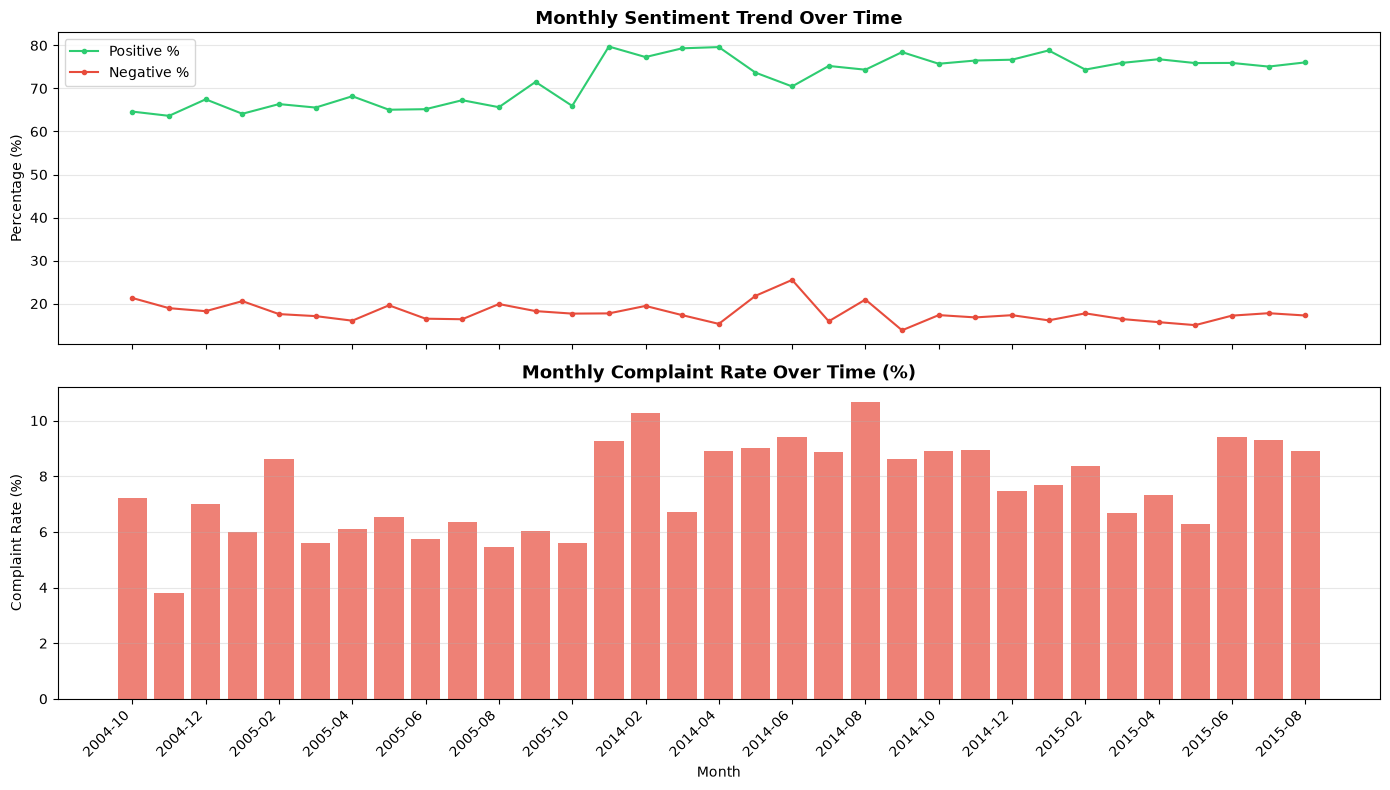

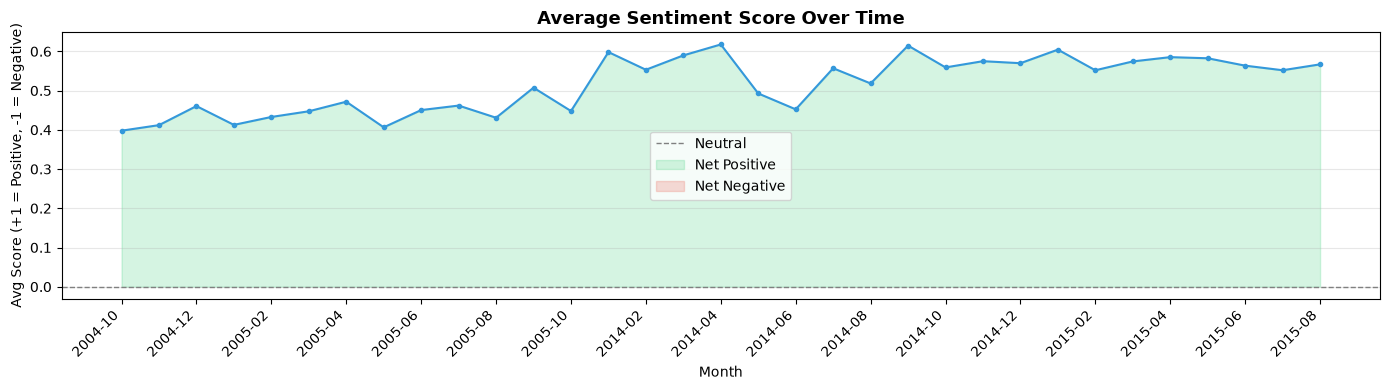

In [11]:
# --- 4. Monthly positive vs negative % — line chart ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly["year_month"], monthly["positive_pct"],
             color="#2ecc71", marker="o", markersize=3, label="Positive %")
axes[0].plot(monthly["year_month"], monthly["negative_pct"],
             color="#e74c3c", marker="o", markersize=3, label="Negative %")
axes[0].set_title("Monthly Sentiment Trend Over Time", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Percentage (%)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# --- 5. Monthly complaint rate — bar chart ---
axes[1].bar(monthly["year_month"], monthly["complaint_rate_pct"],
            color="#e74c3c", alpha=0.7, label="Complaint Rate %")
axes[1].set_title("Monthly Complaint Rate Over Time (%)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Complaint Rate (%)")
axes[1].set_xlabel("Month")
axes[1].grid(axis="y", alpha=0.3)

n = max(1, len(monthly) // 12)
tick_positions = range(0, len(monthly), n)
axes[1].set_xticks(list(tick_positions))
axes[1].set_xticklabels(
    [monthly["year_month"].iloc[i] for i in tick_positions],
    rotation=45, ha="right"
)

plt.tight_layout()
plt.show()

# --- 6. Average sentiment score over time ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly["year_month"], monthly["avg_sentiment"],
        color="#3498db", marker="o", markersize=3)
ax.axhline(0, color="grey", linestyle="--", linewidth=1, label="Neutral")
ax.fill_between(monthly["year_month"], monthly["avg_sentiment"], 0,
                where=(monthly["avg_sentiment"] >= 0),
                alpha=0.2, color="#2ecc71", label="Net Positive")
ax.fill_between(monthly["year_month"], monthly["avg_sentiment"], 0,
                where=(monthly["avg_sentiment"] < 0),
                alpha=0.2, color="#e74c3c", label="Net Negative")
ax.set_title("Average Sentiment Score Over Time", fontsize=13, fontweight="bold")
ax.set_ylabel("Avg Score (+1 = Positive, -1 = Negative)")
ax.set_xlabel("Month")
ax.set_xticks(list(tick_positions))
ax.set_xticklabels(
    [monthly["year_month"].iloc[i] for i in tick_positions],
    rotation=45, ha="right"
)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Complaint Inspection

In [12]:
complaints_sdf = scored_sdf.filter(F.col("is_complaint")).orderBy(F.col("roberta_score").desc())

total = scored_sdf.count()
complaint_count = complaints_sdf.count()
print(f"High-confidence complaints: {complaint_count:,}")
print(f"Complaint rate: {complaint_count/total*100:.1f}%\n")

# Complaints per category
complaints_sdf.groupBy("source_file") \
    .agg(F.count("review_id").alias("complaint_count"),
         F.avg("roberta_score").alias("avg_score")) \
    .orderBy("complaint_count", ascending=False) \
    .show()

# Sample complaint reviews
print("--- Sample complaint reviews ---")
for row in complaints_sdf.select("source_file", "roberta_score", "review").limit(5).collect():
    print(f"[{row.source_file}] score={row.roberta_score:.3f} | {row.review[:200]}")
    print()

26/06/22 18:30:06 WARN TaskSetManager: Stage 42 contains a task of very large size (1183 KiB). The maximum recommended task size is 1000 KiB.
26/06/22 18:30:07 WARN TaskSetManager: Stage 45 contains a task of very large size (1183 KiB). The maximum recommended task size is 1000 KiB.


High-confidence complaints: 2,478
Complaint rate: 8.3%



26/06/22 18:30:07 WARN TaskSetManager: Stage 48 contains a task of very large size (1183 KiB). The maximum recommended task size is 1000 KiB.
26/06/22 18:30:07 WARN TaskSetManager: Stage 49 contains a task of very large size (1183 KiB). The maximum recommended task size is 1000 KiB.


+-----------+---------------+------------------+
|source_file|complaint_count|         avg_score|
+-----------+---------------+------------------+
|     mobile|            587|0.9140396090747956|
|     beauty|            456|0.9107655107713583|
|  furniture|            416|0.9105429547623947|
|    apparel|            396|0.9104861755563756|
|   outdoors|            316|0.9039567773100696|
|      books|            307|0.9011364014218607|
+-----------+---------------+------------------+

--- Sample complaint reviews ---
[mobile] score=0.966 | worst app in the universe. so horibel stupid and horibel sucks and so stupid i'd. give it a -1000 if i could and never get this app

[mobile] score=0.965 | crappy. i hate this game so much. i don't even know why i fell for this scam!!! take my advice and don't use your money and your time on this app. #themostdisapointingappever!!!!!!!

[mobile] score=0.965 | bad game¡. wow i would fell bad if you had to pay for this game because it sucks all ways g

26/06/22 18:30:07 WARN TaskSetManager: Stage 55 contains a task of very large size (1183 KiB). The maximum recommended task size is 1000 KiB.


## 7. Save Results

In [ ]:
OUT_DIR = os.path.abspath("../data/processed/sentiment")

# Full scored dataset
scored_sdf.write.mode("overwrite").parquet(f"{OUT_DIR}/sentiment_scored")

# Monthly trend summary
monthly_sdf.write.mode("overwrite").parquet(f"{OUT_DIR}/sentiment_trend_monthly")

# Complaints only
complaints_sdf.write.mode("overwrite").parquet(f"{OUT_DIR}/complaints")

print("Saved (Spark parquet directories):")
print(f"  {OUT_DIR}/sentiment_scored/")
print(f"  {OUT_DIR}/sentiment_trend_monthly/")
print(f"  {OUT_DIR}/complaints/")

26/06/22 18:30:10 WARN TaskSetManager: Stage 56 contains a task of very large size (1183 KiB). The maximum recommended task size is 1000 KiB.
26/06/22 18:30:11 WARN TaskSetManager: Stage 57 contains a task of very large size (1183 KiB). The maximum recommended task size is 1000 KiB.
26/06/22 18:30:11 WARN TaskSetManager: Stage 65 contains a task of very large size (1183 KiB). The maximum recommended task size is 1000 KiB.
26/06/22 18:30:11 WARN TaskSetManager: Stage 66 contains a task of very large size (1183 KiB). The maximum recommended task size is 1000 KiB.


Saved (Spark parquet directories):
  /Users/varsha/Documents/GitHub/product-review-intelligence-platform/data/processed/sentiment_scored/
  /Users/varsha/Documents/GitHub/product-review-intelligence-platform/data/processed/sentiment_trend_monthly/
  /Users/varsha/Documents/GitHub/product-review-intelligence-platform/data/processed/complaints/


## 8. Per-Product Sentiment Trend

Monthly average sentiment score for the **top 6 products by review volume**, showing how each product's reception shifts over time.

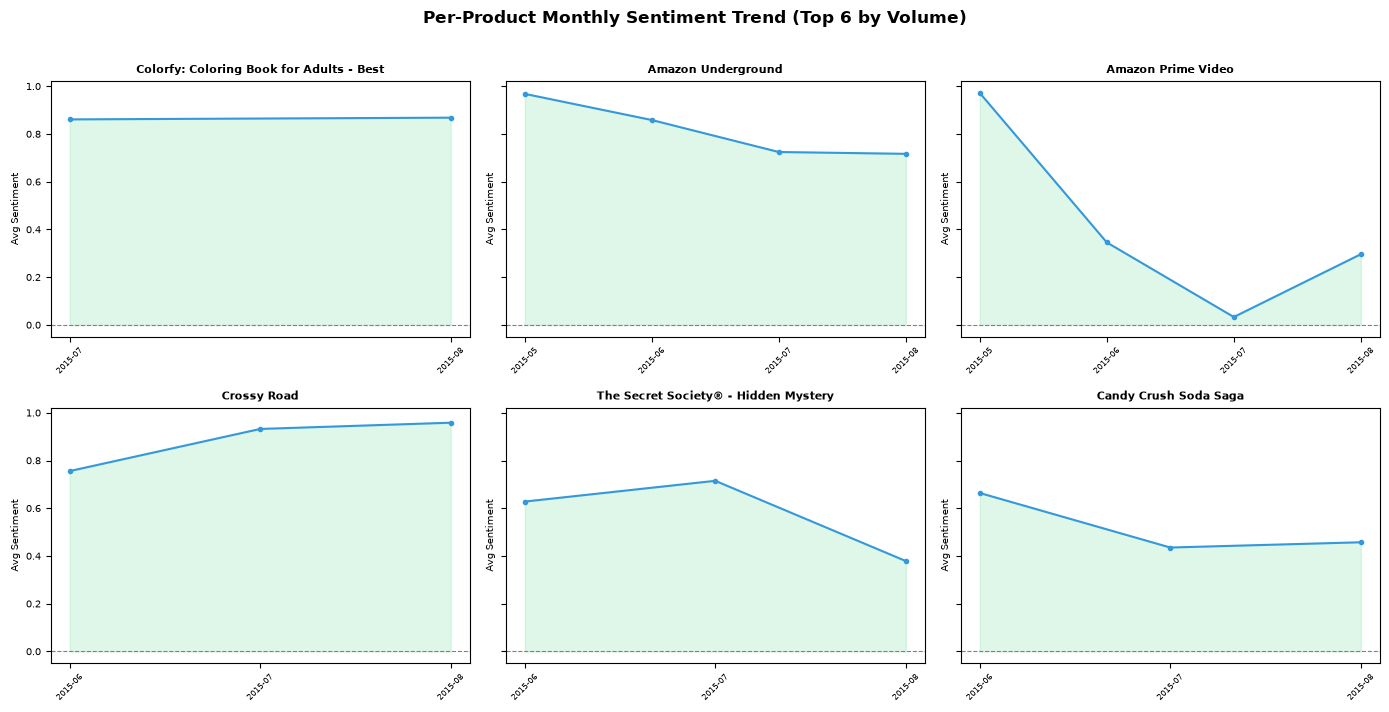

In [17]:
# sentiment_value: +score for positive, -score for negative, 0 for neutral
pdf["sentiment_value"] = pdf.apply(
    lambda r: r["roberta_score"] if r["roberta_label"] == "positive"
    else (-r["roberta_score"] if r["roberta_label"] == "negative" else 0.0),
    axis=1
)

# Top 6 products by review count
top_products = (
    pdf.groupby("product_id")["review_id"].count()
    .nlargest(6)
    .index.tolist()
)

plot_df = pdf[
    pdf["product_id"].isin(top_products) & pdf["review_date"].notna()
].copy()
plot_df["year_month"] = pd.to_datetime(plot_df["review_date"]).dt.to_period("M").astype(str)

product_monthly = (
    plot_df.groupby(["product_id", "product_title", "year_month"])["sentiment_value"]
    .mean()
    .reset_index()
)

# 2x3 grid — one subplot per product
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
axes = axes.flatten()

for ax, pid in zip(axes, top_products):
    data = (
        product_monthly[product_monthly["product_id"] == pid]
        .sort_values("year_month")
    )
    title = data["product_title"].iloc[0][:40] if len(data) else pid

    ax.plot(data["year_month"], data["sentiment_value"],
            color="#3498db", marker="o", markersize=3, linewidth=1.5)
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.fill_between(data["year_month"], data["sentiment_value"], 0,
                    where=(data["sentiment_value"] >= 0), alpha=0.15, color="#2ecc71")
    ax.fill_between(data["year_month"], data["sentiment_value"], 0,
                    where=(data["sentiment_value"] < 0),  alpha=0.15, color="#e74c3c")
    ax.set_title(title, fontsize=8, fontweight="bold")
    ax.set_ylabel("Avg Sentiment", fontsize=7)
    ax.tick_params(axis="x", labelsize=6, rotation=45)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Per-Product Monthly Sentiment Trend (Top 6 by Volume)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()